In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

DATA_PATH = "../../data/gold/mart_overall_analysis/mart_overall_analysis.parquet"
df = pd.read_parquet(DATA_PATH)

TARGET = "o_a_score"
NUMERIC = ["tubersize", "eveness", "appearance", "tubnumbers", "eyedepth",
           "yield", "uniformity", "ffscab", "ffdefects", "ffhollowh", "ff_irs"]
CATEGORICAL = ["env_type", "soil_type", "trial_type"]
GROUP = "name1"

for c in NUMERIC + [TARGET]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Rows: {len(df):,}")
print(f"Varieties: {df[GROUP].nunique():,}")
print(f"Sites: {df['location'].nunique()}   Years: {df['year'].min()}–{df['year'].max()}")

Rows: 29,271
Varieties: 1,240
Sites: 32   Years: 2004–2025


In [3]:
df.describe()

,year,plot,o_a_score,tubersize,eveness,appearance,tubnumbers,eyedepth,uniformity,ffscab,ffdefects,ffhollowh,ff_irs,yield
count,29271.000000,29271.000000,29271.000000,27431.000000,28199.000000,28451.000000,23777.000000,17740.000000,25729.000000,25273.000000,26528.000000,24972.000000,24465.000000,13384.000000
mean,2015.251443,69.086468,6.500639,6.488662,6.443246,6.703508,6.505661,7.049724,6.650740,7.694473,7.400912,8.727235,8.675843,57.605385
std,5.587168,48.505253,0.872344,0.962467,0.849242,0.957447,0.962515,1.764141,1.095084,1.136339,1.155989,1.146166,1.289207,30.307865
min,2004.000000,1.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2011.000000,31.000000,6.000000,6.000000,6.000000,6.000000,6.000000,7.000000,6.000000,8.000000,7.000000,9.000000,9.000000,37.350000
50%,2015.000000,62.000000,6.500000,6.500000,6.500000,7.000000,7.000000,8.000000,7.000000,8.000000,8.000000,9.000000,9.000000,54.300000
75%,2020.000000,99.000000,7.000000,7.000000,7.000000,7.000000,7.000000,8.000000,7.000000,8.000000,8.000000,9.000000,9.000000,75.460000
max,2025.000000,447.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,202.330000


## Dataset balance — environment, soil, trial type

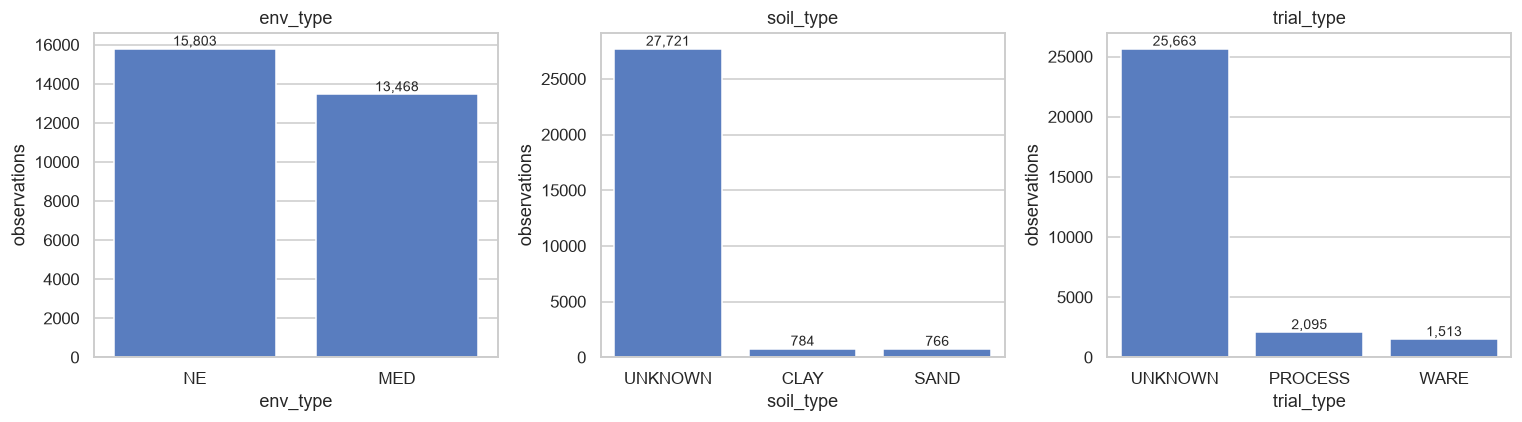


env_type:
env_type
NE     15803
MED    13468

soil_type:
soil_type
UNKNOWN    27721
CLAY         784
SAND         766

trial_type:
trial_type
UNKNOWN    25663
PROCESS     2095
WARE        1513


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, CATEGORICAL):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(f"{col}")
    ax.set_ylabel("observations")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

for col in CATEGORICAL:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())

## 2. Target distribution

The overall appearance score is bounded 0–9. Its shape decides which error
metrics make sense — values near 0 are why MAPE was excluded.

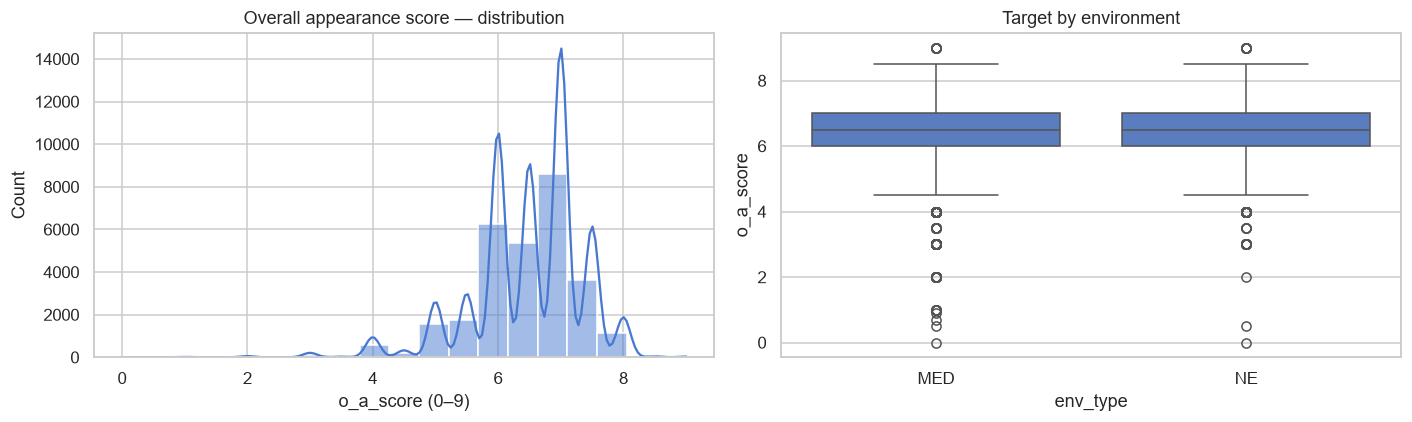

count    29271.000
mean         6.501
std          0.872
min          0.000
25%          6.000
50%          6.500
75%          7.000
max          9.000

Exact-zero scores: 2  (why MAPE is excluded — division by zero)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[TARGET].dropna(), bins=19, kde=True, ax=axes[0])
axes[0].set_title("Overall appearance score — distribution")
axes[0].set_xlabel("o_a_score (0–9)")

sns.boxplot(data=df, x="env_type", y=TARGET, ax=axes[1])
axes[1].set_title("Target by environment")
plt.tight_layout()
plt.show()

print(df[TARGET].describe().round(3).to_string())
print(f"\nExact-zero scores: {(df[TARGET] == 0).sum()}  "
      f"(why MAPE is excluded — division by zero)")

Models predict MED more accurately than NE. But RMSE depends on how spread out
the target is. If NE scores are simply more variable, higher error is expected
and does **not** mean the model is worse there. This table settles it: compare
the standard deviations. If NE's SD is much larger, the gap is scale, not skill.

In [6]:
env_stats = df.groupby("env_type")[TARGET].agg(["mean", "std", "count"]).round(3)
print(env_stats.to_string())

sd_ratio = env_stats.loc["NE", "std"] / env_stats.loc["MED", "std"]
print(f"\nNE/MED standard-deviation ratio: {sd_ratio:.2f}")
print("If this is well above 1, NE's higher RMSE is largely a scale effect.")
print("If it is near 1, NE is genuinely harder to predict — a real finding.")

           mean    std  count
env_type                     
MED       6.393  0.971  13468
NE        6.593  0.766  15803

NE/MED standard-deviation ratio: 0.79
If this is well above 1, NE's higher RMSE is largely a scale effect.
If it is near 1, NE is genuinely harder to predict — a real finding.


## Missing values

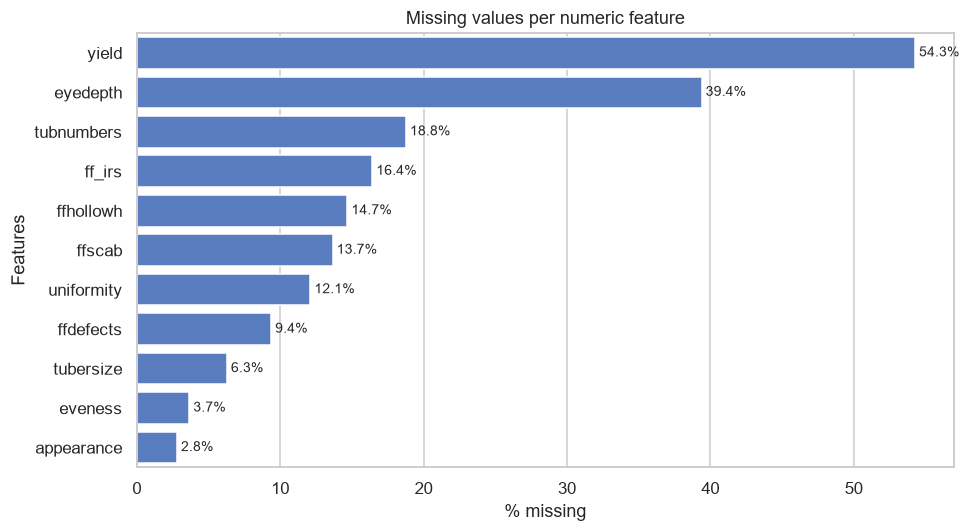

yield         54.3
eyedepth      39.4
tubnumbers    18.8
ff_irs        16.4
ffhollowh     14.7
ffscab        13.7
uniformity    12.1
ffdefects      9.4
tubersize      6.3
eveness        3.7
appearance     2.8


In [7]:
miss_pct = (df[NUMERIC].isna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=miss_pct.values, y=miss_pct.index, ax=ax)
ax.set_title("Missing values per numeric feature")
ax.set_xlabel("% missing")
ax.set_ylabel("Features")
for i, v in enumerate(miss_pct.values):
    ax.text(v, i, f" {v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(miss_pct.round(1).to_string())

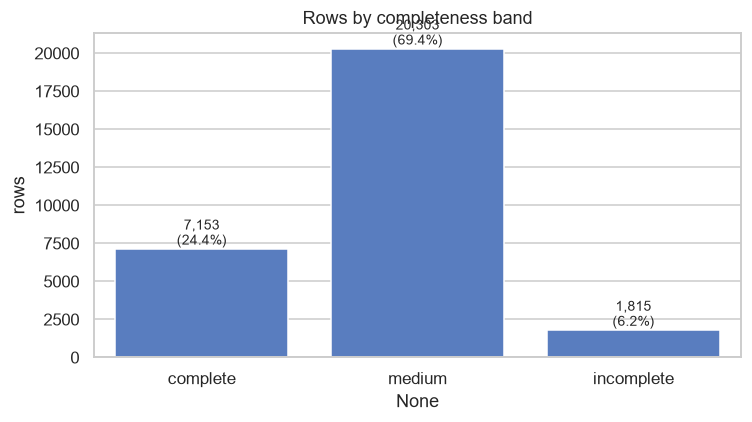

complete       7153
medium        20303
incomplete     1815


In [8]:
miss_frac = df[NUMERIC].isna().mean(axis=1)
bands = pd.cut(miss_frac, [-0.001, 0.0, 0.5, 1.0],
               labels=["complete", "medium", "incomplete"])
band_counts = bands.value_counts().reindex(["complete", "medium", "incomplete"])

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=band_counts.index, y=band_counts.values, ax=ax)
ax.set_title("Rows by completeness band")
ax.set_ylabel("rows")
for i, v in enumerate(band_counts.values):
    ax.text(i, v, f"{v:,}\n({100*v/len(df):.1f}%)", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(band_counts.to_string())

### MNAR

If missingness were random, the target's average would be the same whether a
row is complete or not. If complete and incomplete rows have different target
means, missingness carries information — evidence of MNAR, which justified the
threshold policy over naive imputation.

             mean    std  count
_band                          
complete    6.278  0.957   7153
medium      6.558  0.833  20303
incomplete  6.733  0.784   1815

Different target means across bands => missingness is informative (MNAR-consistent).


C:\Users\mishy\AppData\Local\Temp\ipykernel_43672\1243199169.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mnar = df_band.groupby("_band")[TARGET].agg(["mean", "std", "count"]).round(3)


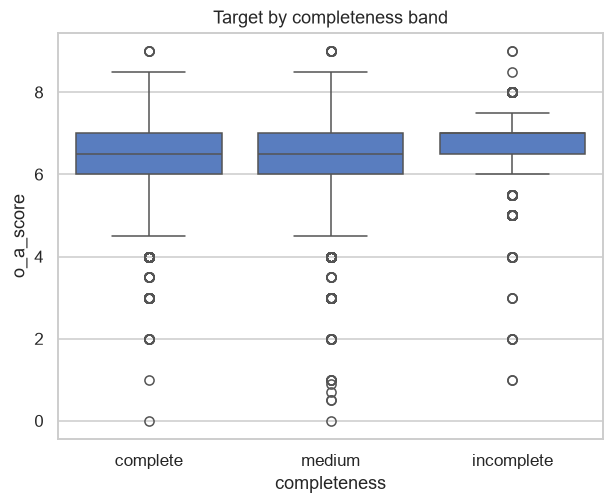

In [9]:
df_band = df.assign(_band=bands)
mnar = df_band.groupby("_band")[TARGET].agg(["mean", "std", "count"]).round(3)
print(mnar.to_string())
print("\nDifferent target means across bands => missingness is informative (MNAR-consistent).")

sns.boxplot(data=df_band, x="_band", y=TARGET,
            order=["complete", "medium", "incomplete"])
plt.title("Target by completeness band")
plt.xlabel("completeness")
plt.show()

## Feature distributions


In [10]:
print(df.describe().round(3).to_string())

for col in NUMERIC:
    print(f"{col}: {df[df[col] > 9].shape[0]}")

            year       plot  o_a_score  tubersize    eveness  appearance  tubnumbers   eyedepth  uniformity     ffscab  ffdefects  ffhollowh     ff_irs      yield
count  29271.000  29271.000  29271.000  27431.000  28199.000   28451.000   23777.000  17740.000   25729.000  25273.000  26528.000  24972.000  24465.000  13384.000
mean    2015.251     69.086      6.501      6.489      6.443       6.704       6.506      7.050       6.651      7.694      7.401      8.727      8.676     57.605
std        5.587     48.505      0.872      0.962      0.849       0.957       0.963      1.764       1.095      1.136      1.156      1.146      1.289     30.308
min     2004.000      1.000      0.000      0.500      0.000       0.000       0.000      0.000       0.000      0.000      0.000      0.000      0.000      0.000
25%     2011.000     31.000      6.000      6.000      6.000       6.000       6.000      7.000       6.000      8.000      7.000      9.000      9.000     37.350
50%     2015.000     6

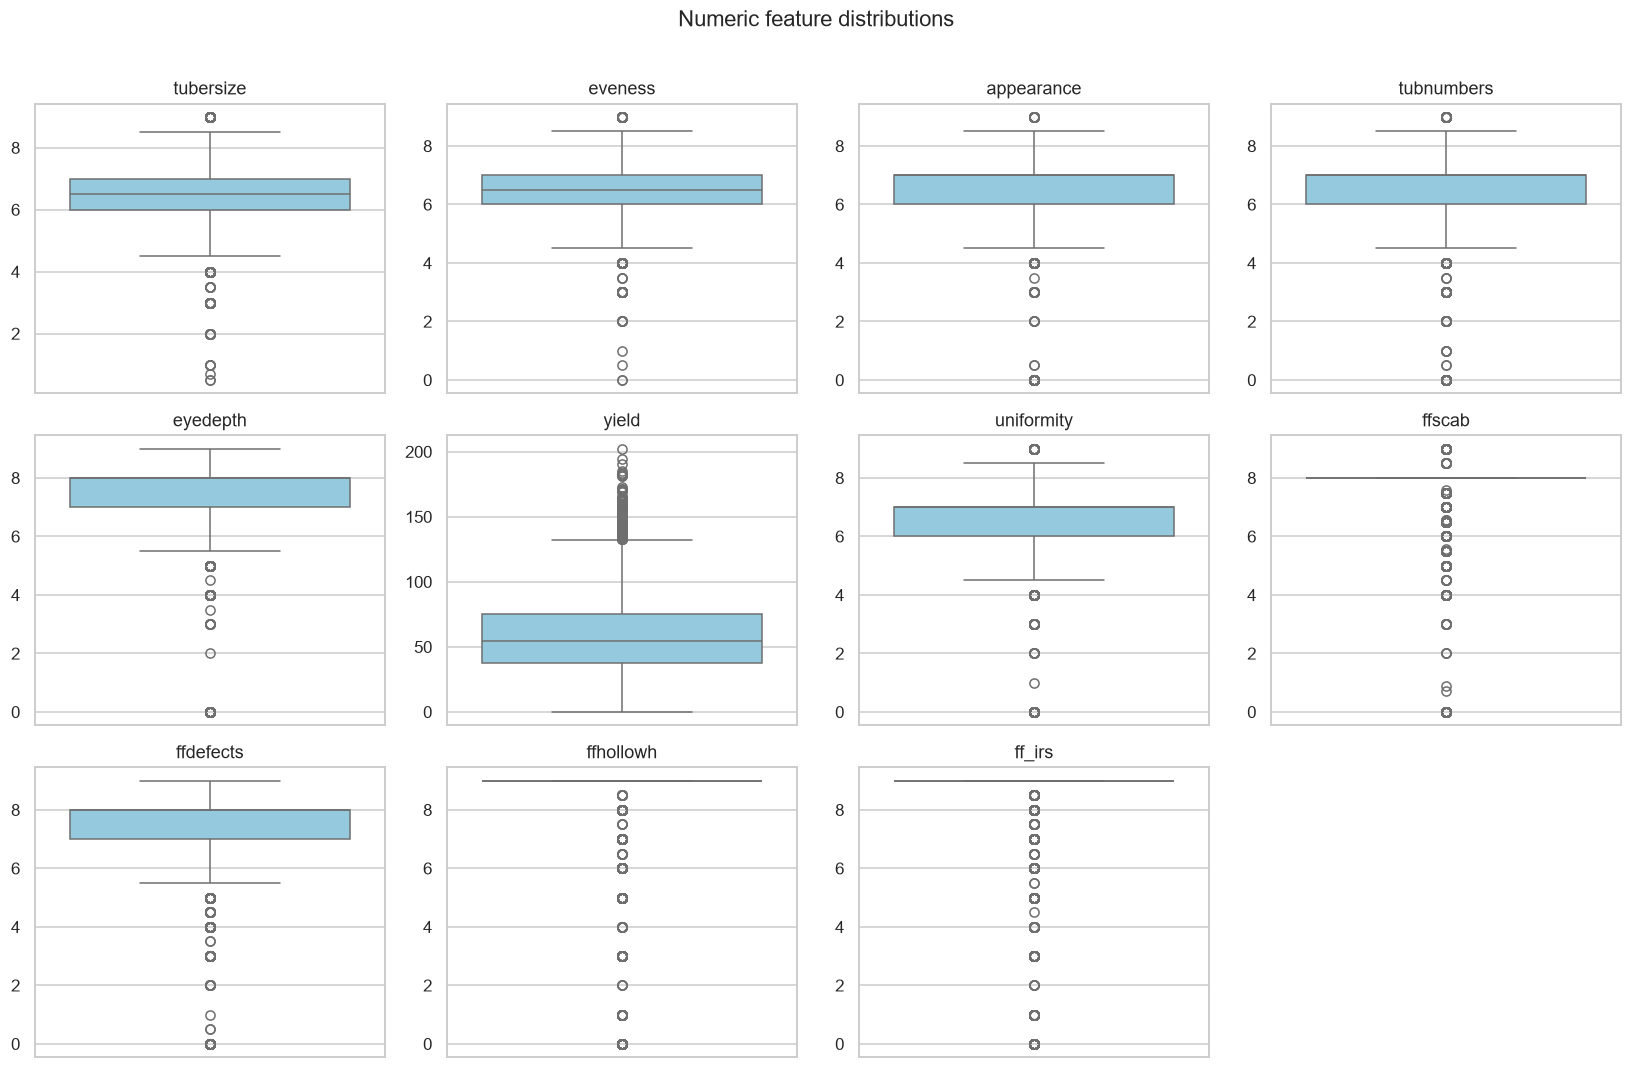

Outliers by 1.5·IQR rule (flagged, not removed):
            n_outliers    pct
ffscab            8498  33.62
ff_irs            2413   9.86
ffhollowh         1968   7.88
eyedepth          1332   7.51
ffdefects         1540   5.81
tubersize         1016   3.70
tubnumbers         671   2.82
uniformity         691   2.69
appearance         562   1.98
eveness            530   1.88
yield              212   1.58


In [11]:
n = len(NUMERIC)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
for ax, col in zip(axes.ravel(), NUMERIC):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(col)
    ax.set_ylabel("")
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.suptitle("Numeric feature distributions", y=1.01)
plt.tight_layout()
plt.show()

def iqr_outliers(s):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum())

out_tbl = pd.DataFrame({
    "n_outliers": {c: iqr_outliers(df[c]) for c in NUMERIC},
    "pct": {c: round(100 * iqr_outliers(df[c]) / df[c].notna().sum(), 2) for c in NUMERIC},
}).sort_values("pct", ascending=False)
print("Outliers by 1.5·IQR rule (flagged, not removed):")
print(out_tbl.to_string())

## Feature correlation map


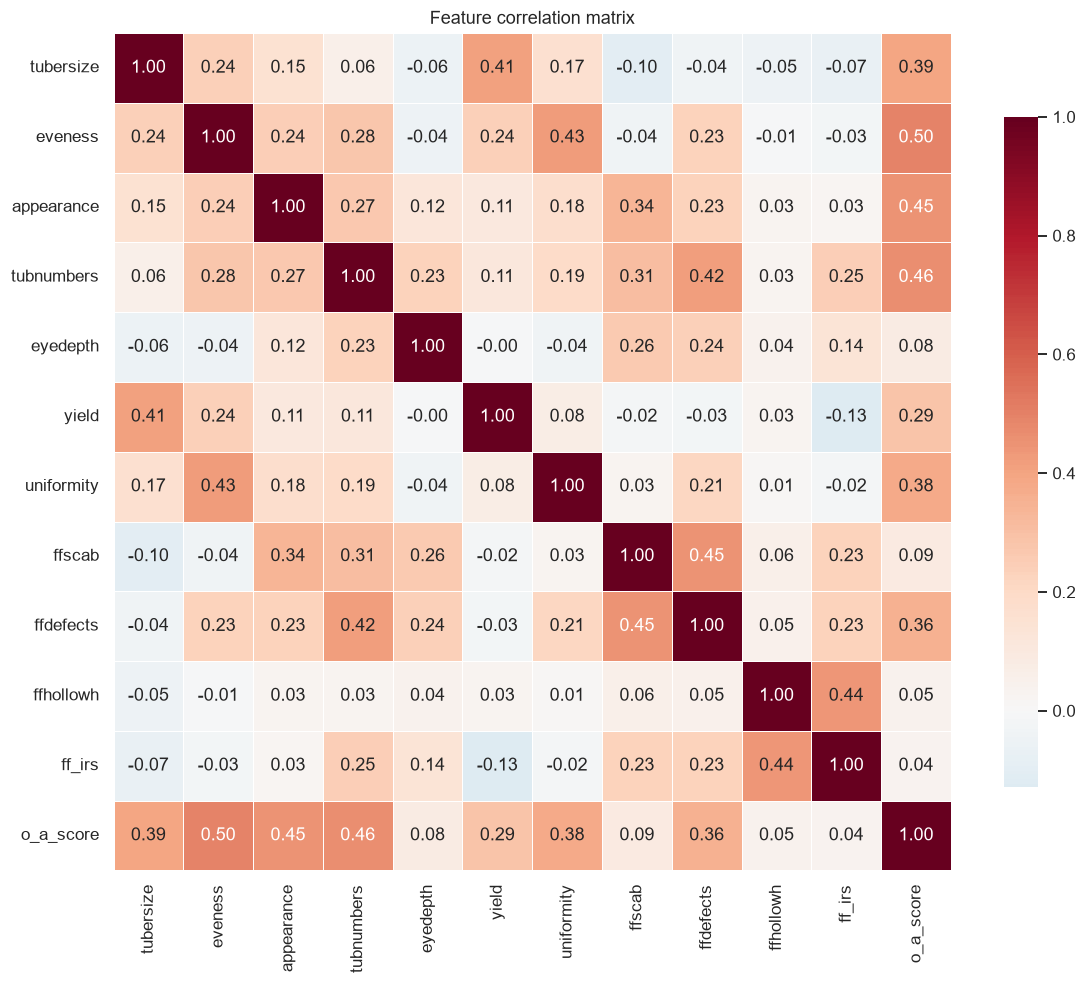


Trait correlation with target:
eveness       0.497
tubnumbers    0.463
appearance    0.453
tubersize     0.395
uniformity    0.377
ffdefects     0.361
yield         0.289
ffscab        0.088
eyedepth      0.082
ffhollowh     0.046
ff_irs        0.036


In [12]:
corr = df[NUMERIC + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

print("\nTrait correlation with target:")
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).round(3).to_string())

## Variety coverage

How many observations each variety has, and how many span both environments.
This decides which analyses are feasible — stability analysis needs varieties
seen across several environments; transfer analysis needs varieties in both
regions.

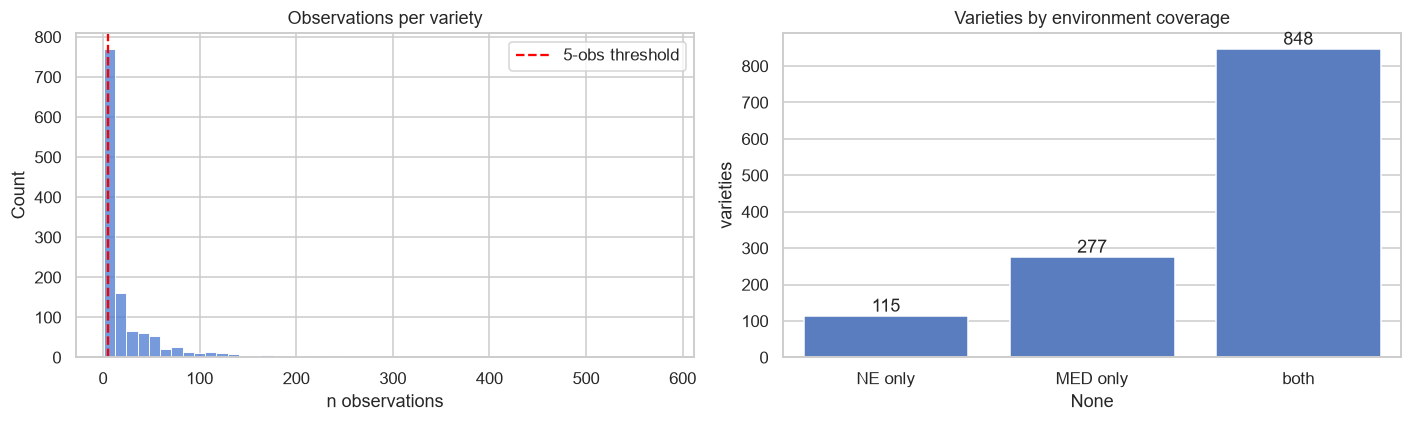

Varieties total: 1,240
  with >=5 observations: 720  (stability analysis is viable on these)
  present in BOTH environments: 848  (transfer analysis pool)

Observations per variety: median=5, max=583, min=1


In [13]:
obs_per_variety = df.groupby(GROUP).size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(obs_per_variety, bins=50, ax=axes[0])
axes[0].set_title("Observations per variety")
axes[0].set_xlabel("n observations")
axes[0].axvline(5, color="red", ls="--", label="5-obs threshold")
axes[0].legend()

env_cov = df.groupby([GROUP, "env_type"]).size().unstack(fill_value=0)
in_both = ((env_cov.get("NE", 0) > 0) & (env_cov.get("MED", 0) > 0)).sum()
ne_only = ((env_cov.get("NE", 0) > 0) & (env_cov.get("MED", 0) == 0)).sum()
med_only = ((env_cov.get("NE", 0) == 0) & (env_cov.get("MED", 0) > 0)).sum()
cov = pd.Series({"NE only": ne_only, "MED only": med_only, "both": in_both})
sns.barplot(x=cov.index, y=cov.values, ax=axes[1])
axes[1].set_title("Varieties by environment coverage")
axes[1].set_ylabel("varieties")
for i, v in enumerate(cov.values):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"Varieties total: {df[GROUP].nunique():,}")
print(f"  with >=5 observations: {(obs_per_variety >= 5).sum():,}  "
      f"(stability analysis is viable on these)")
print(f"  present in BOTH environments: {in_both:,}  "
      f"(transfer analysis pool)")
print(f"\nObservations per variety: median={obs_per_variety.median():.0f}, "
      f"max={obs_per_variety.max()}, min={obs_per_variety.min()}")

### Environments per variety


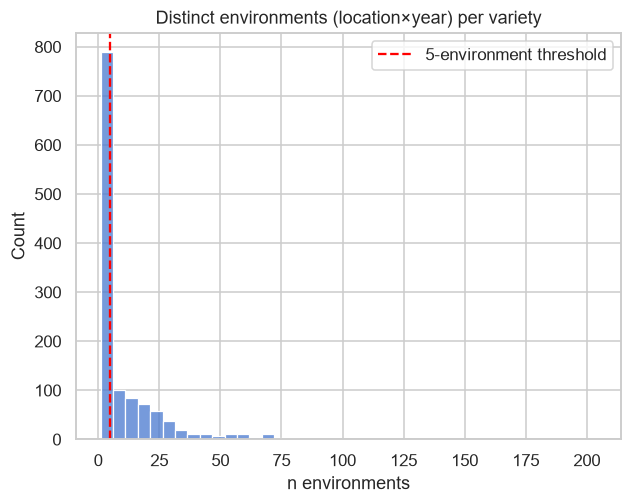

Varieties in >=5 environments: 528  


In [14]:
df["_env_id"] = df["location"].astype(str) + "_" + df["year"].astype(str)
envs_per_variety = df.groupby(GROUP)["_env_id"].nunique()

sns.histplot(envs_per_variety, bins=40)
plt.axvline(5, color="red", ls="--", label="5-environment threshold")
plt.title("Distinct environments (location×year) per variety")
plt.xlabel("n environments")
plt.legend()
plt.show()

print(f"Varieties in >=5 environments: {(envs_per_variety >= 5).sum():,}  ")

## Data-quality summary table

In [15]:
quality = pd.DataFrame({
    "metric": [
        "total rows", "varieties", "sites", "year span",
        "NE rows", "MED rows",
        "complete rows", "medium-missing rows", "incomplete rows",
        "mean missing-fraction (numeric)",
        "target missing", "target exact-zeros",
        "varieties >=5 obs", "varieties in both envs",
    ],
    "value": [
        f"{len(df):,}", f"{df[GROUP].nunique():,}", df["location"].nunique(),
        f"{df['year'].min()}–{df['year'].max()}",
        f"{(df.env_type=='NE').sum():,}", f"{(df.env_type=='MED').sum():,}",
        f"{band_counts['complete']:,}", f"{band_counts['medium']:,}",
        f"{band_counts['incomplete']:,}",
        f"{miss_frac.mean():.3f}",
        f"{df[TARGET].isna().sum():,}", f"{(df[TARGET]==0).sum():,}",
        f"{(obs_per_variety>=5).sum():,}", f"{in_both:,}",
    ],
})
print(quality.to_string(index=False))
# quality.to_csv("eda_quality_summary.csv", index=False)   # uncomment to export

                         metric     value
                     total rows    29,271
                      varieties     1,240
                          sites        32
                      year span 2004–2025
                        NE rows    15,803
                       MED rows    13,468
                  complete rows     7,153
            medium-missing rows    20,303
                incomplete rows     1,815
mean missing-fraction (numeric)     0.174
                 target missing         0
             target exact-zeros         2
              varieties >=5 obs       720
         varieties in both envs       848
